<a href="https://colab.research.google.com/github/Devanshimaheshwari07/ML-PROJECT/blob/main/SVM_%26_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implement Support Vector Machine Classification using Breast Cancer Dataset**

In machine learning, support vector machines (SVMs, also support vector networks) are supervised learning models with associated learning algorithms that analyze data used for
classification and regression analysis.
An SVM model is a representation of the examples as points in space, mapped so that the examples of the separate categories are divided by a clear gap that is as wide as possible.
New examples are then mapped into that same space and,predicted to belong to a category based on which side of the gap they fall. This gap is also called maximum margin and the
SVM classifier is called maximum margin clasifier.
In addition to performing linear classification, SVMs can efficiently perform a non-linear classification using what is called the kernel trick, implicitly mapping their inputs into high-dimensional feature spaces.

In [1]:
#  Breast Cancer Classification: SVM & Decision Tree
#  Dataset: sklearn built-in breast cancer dataset

# Import libraries and load dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')


data = load_breast_cancer()
X            = data.data           # shape: (569, 30)
y            = data.target         # 0 = malignant, 1 = benign
feature_names = data.feature_names
class_names   = data.target_names  # ['malignant', 'benign']

print("=" * 55)
print("  BREAST CANCER DATASET — OVERVIEW")
print("=" * 55)
print(f"  Samples     : {X.shape[0]}")
print(f"  Features    : {X.shape[1]}")
print(f"  Classes     : {list(class_names)}")
print(f"  Malignant   : {np.sum(y == 0)}")
print(f"  Benign      : {np.sum(y == 1)}")
print("=" * 55)




  BREAST CANCER DATASET — OVERVIEW
  Samples     : 569
  Features    : 30
  Classes     : [np.str_('malignant'), np.str_('benign')]
  Malignant   : 212
  Benign      : 357


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

dt       = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]
dt_cv    = cross_val_score(dt, X, y, cv=10)

print(f"Decision Tree — Test Accuracy : {accuracy_score(y_test, dt_pred):.4f}")
print(f"Decision Tree — CV  Accuracy  : {dt_cv.mean():.4f} ± {dt_cv.std():.4f}")
print(classification_report(y_test, dt_pred, target_names=class_names))

Decision Tree — Test Accuracy : 0.9386
Decision Tree — CV  Accuracy  : 0.9211 ± 0.0452
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [11]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)
svm_pred  = svm.predict(X_test_sc)
svm_proba = svm.predict_proba(X_test_sc)[:, 1]
svm_cv    = cross_val_score(
    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    StandardScaler().fit_transform(X), y, cv=10)

print(f"SVM (RBF) — Test Accuracy : {accuracy_score(y_test, svm_pred):.4f}")
print(f"SVM (RBF) — CV  Accuracy  : {svm_cv.mean():.4f} ± {svm_cv.std():.4f}")
print(classification_report(y_test, svm_pred, target_names=class_names))

SVM (RBF) — Test Accuracy : 0.9825
SVM (RBF) — CV  Accuracy  : 0.9771 ± 0.0224
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, dt_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
auc_dt  = auc(fpr_dt,  tpr_dt)
auc_svm = auc(fpr_svm, tpr_svm)

print(f"Decision Tree AUC : {auc_dt:.4f}")
print(f"SVM (RBF)  AUC    : {auc_svm:.4f}")

Decision Tree AUC : 0.9342
SVM (RBF)  AUC    : 0.9950


In [15]:
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)

dt_pca  = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_tr_p, y_tr_p)
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale',
              probability=True, random_state=42).fit(X_tr_p, y_tr_p)
print("PCA complete")

PCA complete


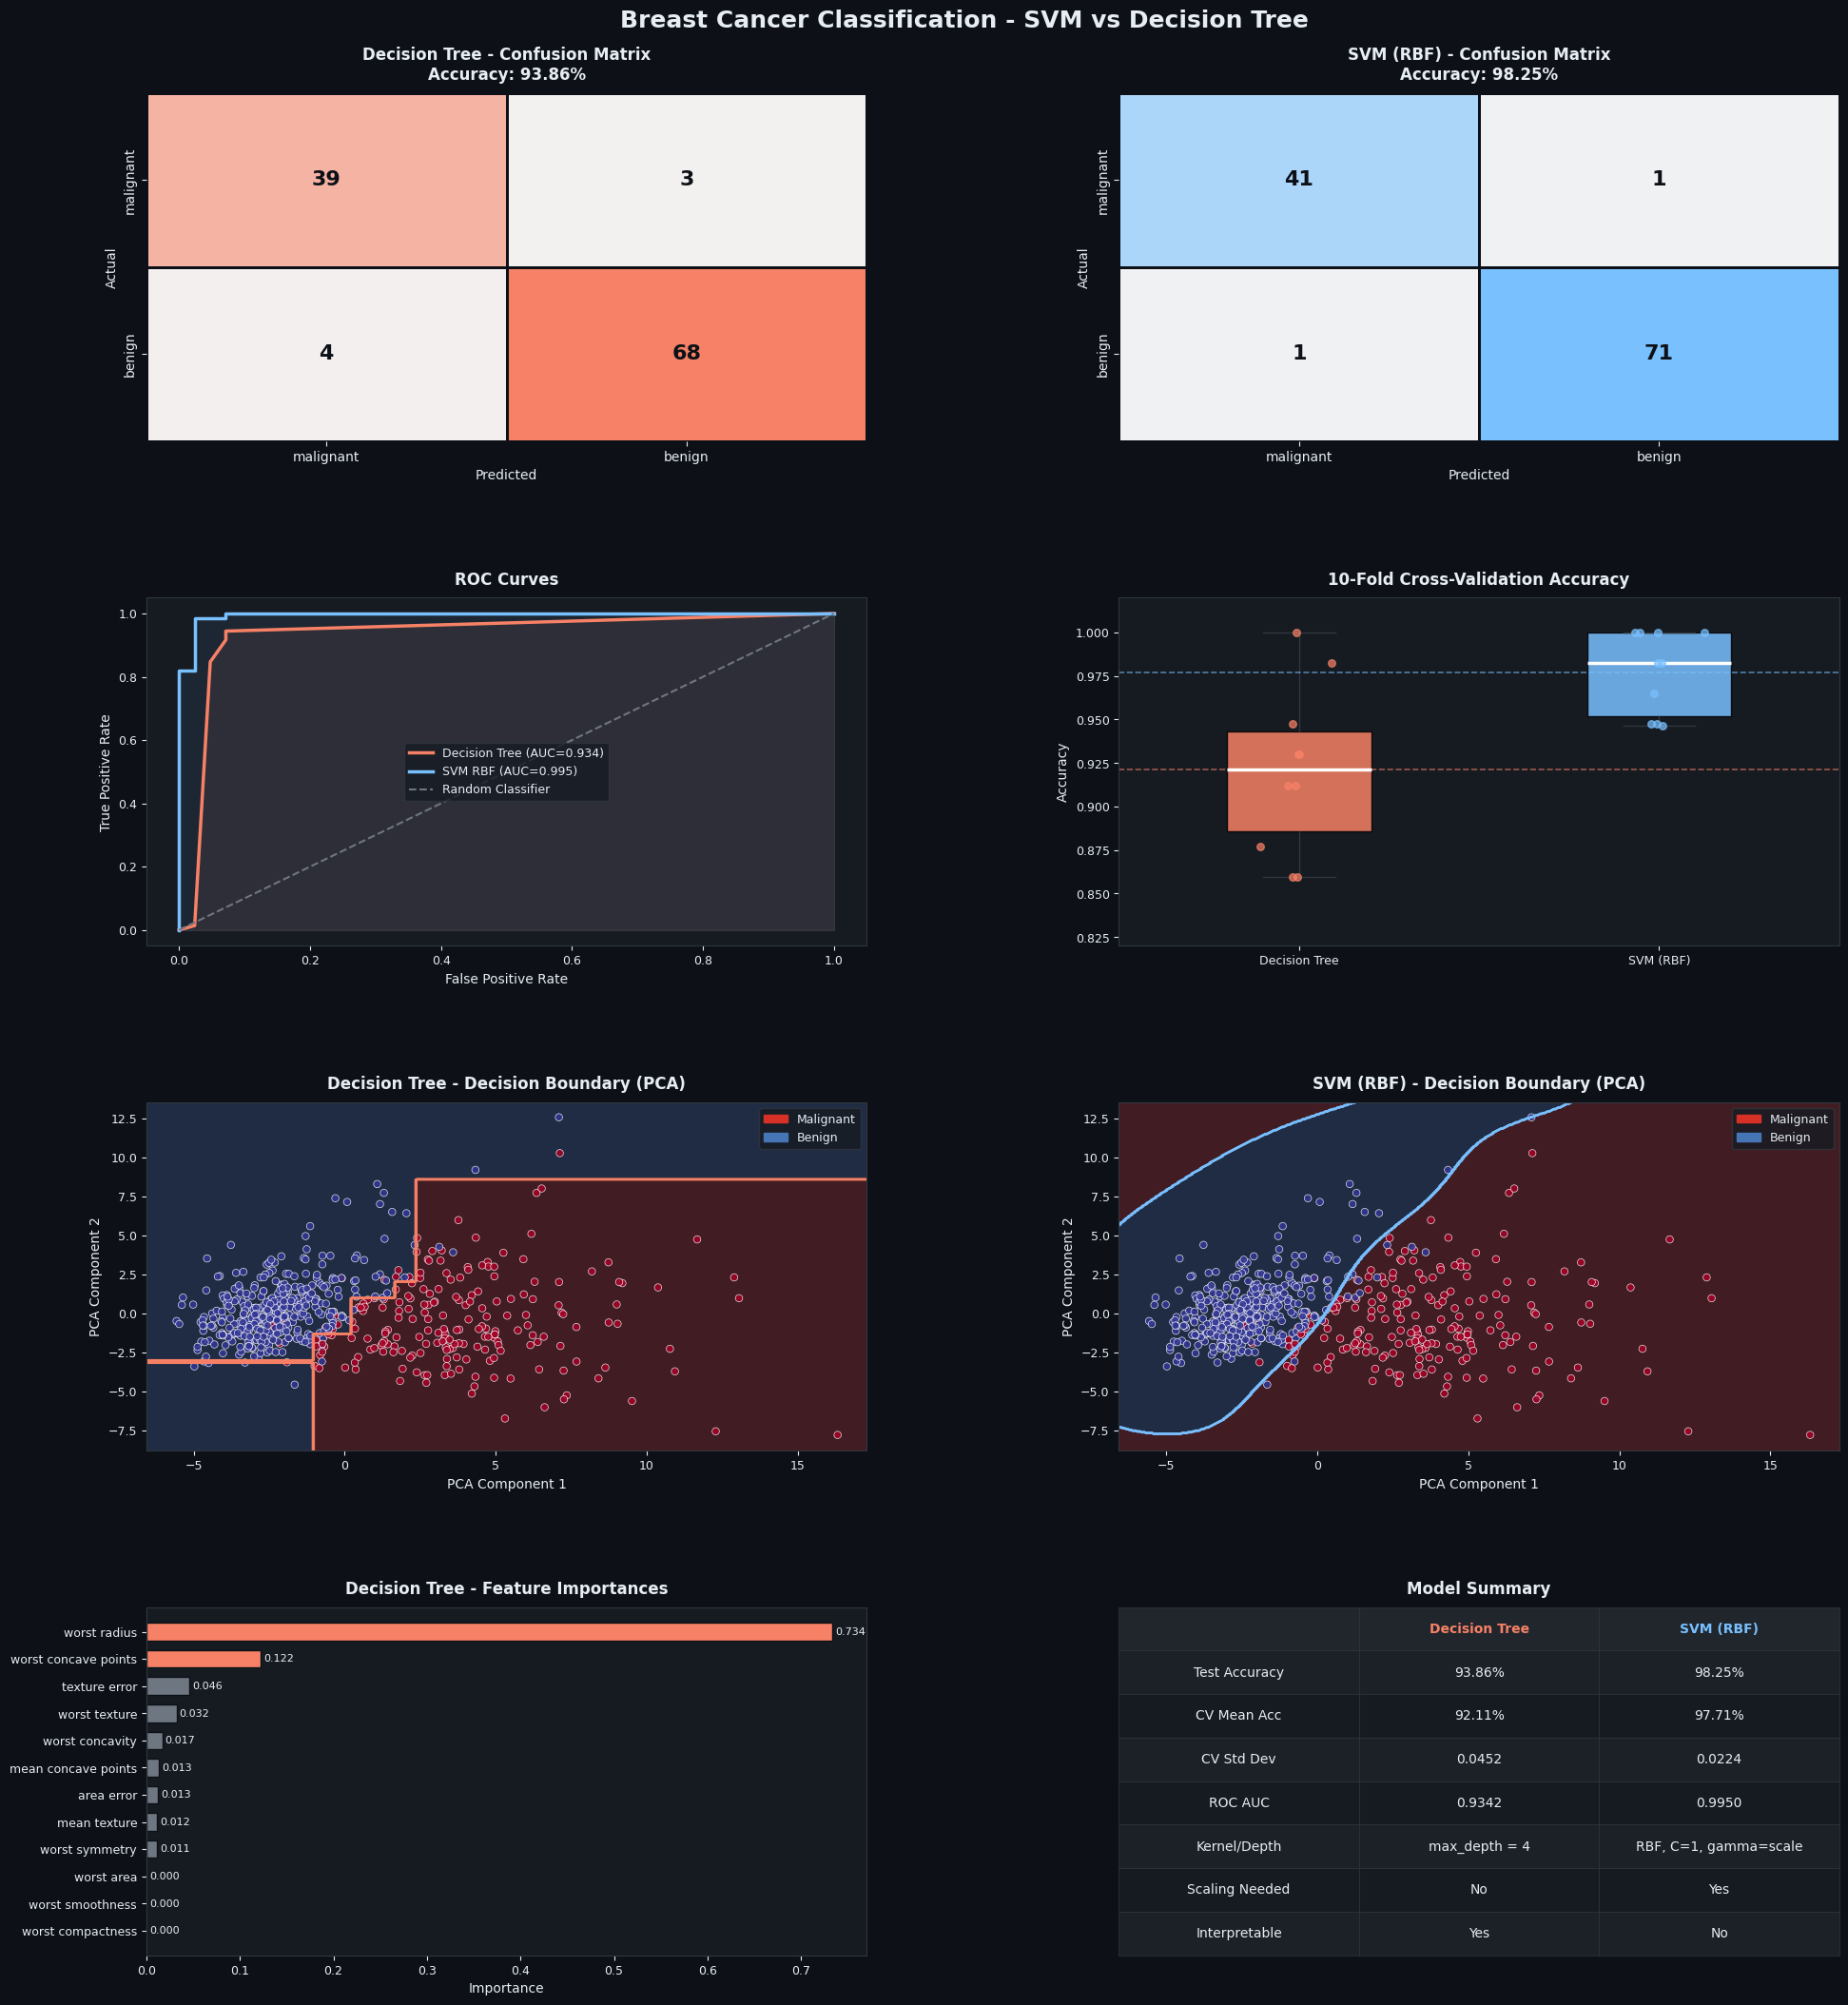

In [14]:
DARK='#0d1117'; PANEL='#161b22'; DT_C='#f78166'; SVM_C='#79c0ff'; TEXT='#e6edf3'; GRID='#30363d'
plt.rcParams.update({'font.family': 'DejaVu Sans'})

fig = plt.figure(figsize=(20, 22), facecolor=DARK)
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35,
                        top=0.93, bottom=0.04, left=0.07, right=0.96)

def style_ax(ax, title):
    ax.set_facecolor(PANEL); ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=10)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)

# Confusion Matrices
for i, (pred, name, color) in enumerate([(dt_pred,'Decision Tree',DT_C),(svm_pred,'SVM (RBF)',SVM_C)]):
    ax = fig.add_subplot(gs[0, i])
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=class_names, yticklabels=class_names,
                linewidths=2, linecolor=DARK, cbar=False,
                annot_kws={'size':16,'weight':'bold','color':DARK})
    ax.set_facecolor(PANEL); ax.tick_params(colors=TEXT)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.set_xlabel('Predicted', color=TEXT, fontsize=10)
    ax.set_ylabel('Actual',    color=TEXT, fontsize=10)
    ax.set_title(f'{name} - Confusion Matrix\nAccuracy: {accuracy_score(y_test,pred):.2%}',
                 color=TEXT, fontsize=12, fontweight='bold', pad=10)

# ROC Curves
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr_dt, tpr_dt,   color=DT_C,  lw=2.5, label=f'Decision Tree (AUC={auc_dt:.3f})')
ax3.plot(fpr_svm, tpr_svm, color=SVM_C, lw=2.5, label=f'SVM RBF (AUC={auc_svm:.3f})')
ax3.plot([0,1],[0,1],'--', color='#6e7681', lw=1.5, label='Random Classifier')
ax3.fill_between(fpr_dt, tpr_dt, alpha=0.08, color=DT_C)
ax3.fill_between(fpr_svm, tpr_svm, alpha=0.08, color=SVM_C)
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate',  fontsize=10)
ax3.legend(fontsize=9, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
style_ax(ax3, 'ROC Curves')

# CV Boxplot
ax4 = fig.add_subplot(gs[1, 1])
bp = ax4.boxplot([dt_cv, svm_cv], positions=[1,2], patch_artist=True, widths=0.4,
                  medianprops=dict(color='white', linewidth=2.5),
                  whiskerprops=dict(color=GRID), capprops=dict(color=GRID),
                  flierprops=dict(marker='o', markerfacecolor=TEXT, markersize=5))
bp['boxes'][0].set(facecolor=DT_C, alpha=0.85)
bp['boxes'][1].set(facecolor=SVM_C, alpha=0.85)
for cv, pos, color in [(dt_cv,1,DT_C),(svm_cv,2,SVM_C)]:
    ax4.scatter(np.random.normal(pos,0.04,len(cv)), cv, color=color, alpha=0.7, s=30, zorder=5)
ax4.set_xticks([1,2]); ax4.set_xticklabels(['Decision Tree','SVM (RBF)'], fontsize=10)
ax4.set_ylabel('Accuracy', fontsize=10); ax4.set_ylim(0.82, 1.02)
ax4.axhline(dt_cv.mean(), color=DT_C, linestyle='--', lw=1.2, alpha=0.6)
ax4.axhline(svm_cv.mean(), color=SVM_C, linestyle='--', lw=1.2, alpha=0.6)
style_ax(ax4, '10-Fold Cross-Validation Accuracy')

# Decision Boundaries
h = 0.05
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
for i, (mdl, name, color) in enumerate([(dt_pca,'Decision Tree',DT_C),(svm_pca,'SVM (RBF)',SVM_C)]):
    ax = fig.add_subplot(gs[2, i])
    Z = mdl.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    ax.contour(xx, yy, Z, colors=[color], linewidths=1.5, alpha=0.7)
    ax.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap=plt.cm.RdYlBu,
               edgecolors='white', linewidths=0.5, s=30, alpha=0.85)
    p0 = mpatches.Patch(color='#d73027', label='Malignant')
    p1 = mpatches.Patch(color='#4575b4', label='Benign')
    ax.legend(handles=[p0,p1], fontsize=9, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
    ax.set_xlabel('PCA Component 1', fontsize=10)
    ax.set_ylabel('PCA Component 2', fontsize=10)
    style_ax(ax, f'{name} - Decision Boundary (PCA)')

# Feature Importances
ax7 = fig.add_subplot(gs[3, 0])
fi = dt.feature_importances_
top_idx = np.argsort(fi)[-12:]
colors_fi = [DT_C if fi[j] > 0.05 else '#6e7681' for j in top_idx]
bars = ax7.barh(feature_names[top_idx], fi[top_idx], color=colors_fi, edgecolor=DARK, height=0.65)
for bar, val in zip(bars, fi[top_idx]):
    ax7.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', color=TEXT, fontsize=8)
ax7.set_xlabel('Importance', fontsize=10)
style_ax(ax7, 'Decision Tree - Feature Importances')

# Summary Table
ax8 = fig.add_subplot(gs[3, 1])
ax8.set_facecolor(PANEL); ax8.axis('off')
metrics = [
    ('',               'Decision Tree',                           'SVM (RBF)'),
    ('Test Accuracy',  f'{accuracy_score(y_test, dt_pred):.2%}', f'{accuracy_score(y_test, svm_pred):.2%}'),
    ('CV Mean Acc',    f'{dt_cv.mean():.2%}',                    f'{svm_cv.mean():.2%}'),
    ('CV Std Dev',     f'{dt_cv.std():.4f}',                     f'{svm_cv.std():.4f}'),
    ('ROC AUC',        f'{auc_dt:.4f}',                          f'{auc_svm:.4f}'),
    ('Kernel/Depth',   'max_depth = 4',                          'RBF, C=1, gamma=scale'),
    ('Scaling Needed', 'No',                                     'Yes'),
    ('Interpretable',  'Yes',                                    'No'),
]
table = ax8.table(cellText=metrics, cellLoc='center', loc='center', bbox=[0,0,1,1])
table.auto_set_font_size(False); table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(GRID); cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor('#21262d')
        cell.set_text_props(color=DT_C if col==1 else SVM_C if col==2 else TEXT, fontweight='bold')
    else:
        cell.set_facecolor('#161b22' if row%2==0 else '#1c2128')
        cell.set_text_props(color=TEXT)
ax8.set_title('Model Summary', color=TEXT, fontsize=12, fontweight='bold', pad=10)

fig.suptitle('Breast Cancer Classification - SVM vs Decision Tree',
             color=TEXT, fontsize=18, fontweight='bold', y=0.97)
plt.tight_layout()
plt.show()